# Detecção de Fraudes em Transações de Cartão de Crédito

Este projeto tem como objetivo desenvolver e avaliar modelos de Machine Learning capazes de identificar possíveis fraudes em transações de cartão de crédito.

O conjunto de dados apresenta um forte desbalanceamento entre as classes, com aproximadamente 99,83% das transações classificadas como normais e apenas 0,17% como fraudulentas.

Durante o projeto foram utilizados três modelos de classificação:

- Regressão Logística
- Random Forest
- XGBoost

A avaliação dos modelos considera principalmente as métricas de precisão, recall e F1-Score da classe fraude. Também são utilizadas as curvas ROC e Precision-Recall, além da análise de importância das variáveis e SHAP para interpretação do modelo.

## 1. Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas para manipulação dos dados, cálculos numéricos e criação das visualizações.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Carregamento do Dataset

Nesta etapa, o conjunto de dados de transações de cartão de crédito é carregado para análise. Cada linha representa uma transação e a coluna `Class` indica sua classificação:

- `0` = transação normal
- `1` = fraude

As variáveis `V1` a `V28` foram previamente transformadas por PCA, enquanto `Time` e `Amount` representam informações relacionadas ao tempo e ao valor das transações.

In [2]:
!pip install kagglehub -q

import kagglehub
import os

# Baixa automaticamente o dataset do Kaggle
caminho = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Dataset baixado em:", caminho)
print(os.listdir(caminho))

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset baixado em: /kaggle/input/creditcardfraud
['creditcard.csv']


In [3]:
df = pd.read_csv(os.path.join(caminho, 'creditcard.csv'))

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Análise Exploratória dos Dados

Nesta etapa são analisadas as principais características do conjunto de dados, incluindo suas dimensões, distribuição das classes, presença de valores ausentes e estatísticas das transações.

Um dos principais desafios deste problema é o forte desbalanceamento das classes. A quantidade de transações fraudulentas é muito menor do que a quantidade de transações normais, tornando métricas como precisão, recall e F1-Score especialmente importantes para a avaliação dos modelos.

In [4]:
print("Quantidade de linhas e colunas:")
print(df.shape)

print("\nQuantidade de transações por classe:")
print(df['Class'].value_counts())

print("\nPorcentagem de cada classe:")
print(df['Class'].value_counts(normalize=True) * 100)

Quantidade de linhas e colunas:
(284807, 31)

Quantidade de transações por classe:
Class
0    284315
1       492
Name: count, dtype: int64

Porcentagem de cada classe:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [5]:
print("Informações do dataset:")
df.info()

print("\nValores ausentes:")
print(df.isnull().sum().sum())

print("\nEstatísticas de Amount:")
print(df['Amount'].describe())

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null 

## 4. Preparação dos Dados

Nesta etapa, os dados são preparados para o treinamento dos modelos.

Foi criada a variável `Amount_Log`, utilizando uma transformação logarítmica sobre o valor das transações (`Amount`). Em seguida, os dados foram separados em conjuntos de treino e teste, mantendo a proporção entre transações normais e fraudulentas por meio do parâmetro `stratify`.

As variáveis `Time`, `Amount` e `Amount_Log` foram padronizadas utilizando `StandardScaler`. O ajuste do scaler foi realizado apenas sobre os dados de treinamento, evitando vazamento de informações do conjunto de teste.

In [6]:
# Cria uma nova variável com o log do valor da transação
df['Amount_Log'] = np.log1p(df['Amount'])

df[['Amount', 'Amount_Log']].head()

,Amount,Amount_Log
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separa as variáveis de entrada e a variável alvo
X = df.drop('Class', axis=1)
y = df['Class']

# Primeiro separa treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Cria cópias dos dados
X_train = X_train.copy()
X_test = X_test.copy()

# Padroniza apenas depois da separação
scaler = StandardScaler()
colunas_padronizar = ['Time', 'Amount', 'Amount_Log']

X_train[colunas_padronizar] = scaler.fit_transform(
    X_train[colunas_padronizar]
)

X_test[colunas_padronizar] = scaler.transform(
    X_test[colunas_padronizar]
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nClasses no treino:")
print(y_train.value_counts())

print("\nClasses no teste:")
print(y_test.value_counts())

Treino: (227845, 31)
Teste: (56962, 31)

Classes no treino:
Class
0    227451
1       394
Name: count, dtype: int64

Classes no teste:
Class
0    56864
1       98
Name: count, dtype: int64


## 5. Treinamento e Avaliação dos Modelos

Nesta etapa são treinados três modelos de classificação: Regressão Logística, Random Forest e XGBoost.

Como o conjunto de dados é fortemente desbalanceado, foram utilizados mecanismos de ponderação das classes para aumentar a importância das transações fraudulentas durante o treinamento.

Os modelos são avaliados principalmente pelas métricas de precisão, recall e F1-Score da classe fraude.

### 5.1 Regressão Logística

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Cria e treina o modelo
modelo_logistico = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

modelo_logistico.fit(X_train, y_train)

# Faz previsões com os dados de teste
y_pred_logistico = modelo_logistico.predict(X_test)

# Mostra os resultados
print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_logistico))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_logistico, digits=4))

Matriz de confusão:
[[55488  1376]
 [    8    90]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.9999    0.9758    0.9877     56864
           1     0.0614    0.9184    0.1151        98

    accuracy                         0.9757     56962
   macro avg     0.5306    0.9471    0.5514     56962
weighted avg     0.9982    0.9757    0.9862     56962



### 5.2 Random Forest

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Cria o modelo Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Treina o modelo
modelo_rf.fit(X_train, y_train)

# Faz as previsões
y_pred_rf = modelo_rf.predict(X_test)

# Mostra os resultados
print("Matriz de confusão - Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRelatório de classificação - Random Forest:")
print(classification_report(y_test, y_pred_rf, digits=4))

Matriz de confusão - Random Forest:
[[56861     3]
 [   24    74]]

Relatório de classificação - Random Forest:
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9610    0.7551    0.8457        98

    accuracy                         0.9995     56962
   macro avg     0.9803    0.8775    0.9227     56962
weighted avg     0.9995    0.9995    0.9995     56962



### 5.3 XGBoost

In [10]:
!pip install xgboost -q

In [11]:
from xgboost import XGBClassifier

# Calcula o peso da classe de fraude
peso_fraude = (y_train == 0).sum() / (y_train == 1).sum()

# Cria o modelo XGBoost
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=peso_fraude,
    random_state=42,
    eval_metric='logloss'
)

# Treina o modelo
modelo_xgb.fit(X_train, y_train)

# Faz as previsões
y_pred_xgb = modelo_xgb.predict(X_test)

print("Matriz de confusão - XGBoost:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nRelatório de classificação - XGBoost:")
print(classification_report(y_test, y_pred_xgb, digits=4))

Matriz de confusão - XGBoost:
[[56703   161]
 [   13    85]]

Relatório de classificação - XGBoost:
              precision    recall  f1-score   support

           0     0.9998    0.9972    0.9985     56864
           1     0.3455    0.8673    0.4942        98

    accuracy                         0.9969     56962
   macro avg     0.6726    0.9323    0.7463     56962
weighted avg     0.9986    0.9969    0.9976     56962



## 6. Comparação dos Modelos

Após o treinamento, os três modelos são comparados utilizando as métricas de precisão, recall e F1-Score da classe fraude.

Essa comparação permite observar o equilíbrio entre a capacidade de detectar transações fraudulentas e a quantidade de falsos positivos gerados por cada modelo.

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

resultados = pd.DataFrame({
    'Modelo': [
        'Regressão Logística',
        'Random Forest',
        'XGBoost'
    ],
    'Precisão': [
        precision_score(y_test, y_pred_logistico),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistico),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_logistico),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

resultados

,Modelo,Precisão,Recall,F1-Score
0,Regressão Logística,0.061392,0.918367,0.115090
1,Random Forest,0.961039,0.755102,0.845714
2,XGBoost,0.345528,0.867347,0.494186


## 7. Ajuste do Limiar de Classificação

Por padrão, o modelo utiliza um limiar de 0,5 para classificar uma transação como fraude. Entretanto, em problemas de detecção de fraude, pode ser interessante reduzir esse limiar para aumentar o recall e identificar uma maior quantidade de transações fraudulentas.

Foram testados diferentes limiares entre 0,1 e 0,5. Com base nos resultados, foi escolhido o limiar de **0,3**, que aumentou o recall da classe fraude para aproximadamente **89,80%**, embora tenha reduzido a precisão devido ao aumento de falsos positivos.

In [13]:
# Probabilidade de cada transação ser fraude
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Testa diferentes limiares
limiares = [0.1, 0.2, 0.3, 0.4, 0.5]

for limiar in limiares:
    y_pred_limiar = (y_prob_xgb >= limiar).astype(int)

    precisao = precision_score(y_test, y_pred_limiar)
    recall = recall_score(y_test, y_pred_limiar)
    f1 = f1_score(y_test, y_pred_limiar)

    print(f"Limiar: {limiar}")
    print(f"Precisão: {precisao:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("-" * 30)

Limiar: 0.1
Precisão: 0.0560
Recall: 0.9082
F1-Score: 0.1055
------------------------------
Limiar: 0.2
Precisão: 0.1180
Recall: 0.8980
F1-Score: 0.2085
------------------------------
Limiar: 0.3
Precisão: 0.1857
Recall: 0.8980
F1-Score: 0.3077
------------------------------
Limiar: 0.4
Precisão: 0.2652
Recall: 0.8878
F1-Score: 0.4085
------------------------------
Limiar: 0.5
Precisão: 0.3455
Recall: 0.8673
F1-Score: 0.4942
------------------------------


In [14]:
# Limiar escolhido
limiar_escolhido = 0.3

# Nova classificação utilizando o limiar
y_pred_xgb_ajustado = (y_prob_xgb >= limiar_escolhido).astype(int)

print("Matriz de confusão - XGBoost com limiar 0.3:")
print(confusion_matrix(y_test, y_pred_xgb_ajustado))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_xgb_ajustado, digits=4))

Matriz de confusão - XGBoost com limiar 0.3:
[[56478   386]
 [   10    88]]

Relatório de classificação:
              precision    recall  f1-score   support

           0     0.9998    0.9932    0.9965     56864
           1     0.1857    0.8980    0.3077        98

    accuracy                         0.9930     56962
   macro avg     0.5927    0.9456    0.6521     56962
weighted avg     0.9984    0.9930    0.9953     56962



## 8. Curvas ROC e Precision-Recall

Para avaliar o desempenho dos modelos em diferentes limiares de classificação, são utilizadas as curvas ROC e Precision-Recall.

A curva ROC apresenta a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos. Já a curva Precision-Recall é especialmente relevante neste projeto devido ao forte desbalanceamento entre as classes.

Também são calculadas as métricas AUC e Average Precision (AP) para auxiliar na comparação entre os modelos.

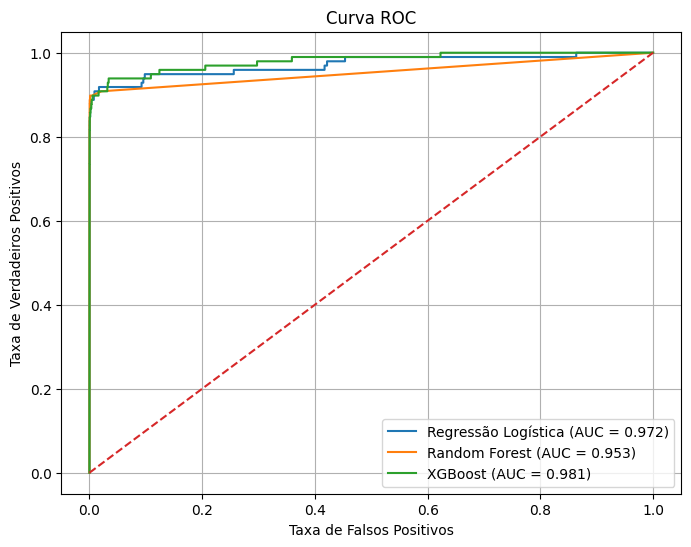

In [15]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# Probabilidades de fraude dos três modelos
y_prob_logistico = modelo_logistico.predict_proba(X_test)[:, 1]
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Calcula as curvas ROC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistico)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Calcula AUC
auc_log = roc_auc_score(y_test, y_prob_logistico)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Gráfico ROC
plt.figure(figsize=(8, 6))

plt.plot(fpr_log, tpr_log, label=f'Regressão Logística (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')

plt.plot([0, 1], [0, 1], '--')

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid()

plt.show()

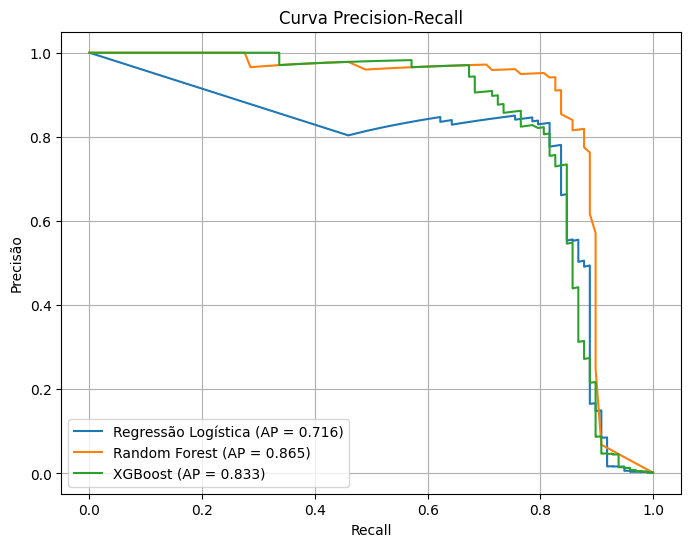

In [16]:
# Calcula as curvas Precision-Recall
precision_log, recall_log, _ = precision_recall_curve(
    y_test, y_prob_logistico
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test, y_prob_rf
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test, y_prob_xgb
)

# Average Precision
ap_log = average_precision_score(y_test, y_prob_logistico)
ap_rf = average_precision_score(y_test, y_prob_rf)
ap_xgb = average_precision_score(y_test, y_prob_xgb)

# Gráfico Precision-Recall
plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label=f'Regressão Logística (AP = {ap_log:.3f})'
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f'Random Forest (AP = {ap_rf:.3f})'
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label=f'XGBoost (AP = {ap_xgb:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid()

plt.show()

## 9. Importância das Variáveis e SHAP

Após a avaliação dos modelos, é realizada uma análise para compreender quais variáveis possuem maior influência nas previsões do XGBoost.

Primeiramente, é analisada a importância das variáveis fornecida pelo próprio modelo. Em seguida, é utilizado o SHAP (SHapley Additive exPlanations), que permite visualizar como os valores das variáveis contribuem para aumentar ou reduzir a saída do modelo em direção à classe fraude.

Como as variáveis `V1` a `V28` foram transformadas por PCA, seus significados originais não estão disponíveis diretamente.

10 variáveis mais importantes:
V14       0.410675
V4        0.051165
V10       0.049330
V12       0.040171
V20       0.040148
V8        0.032901
V28       0.026157
Amount    0.023993
V26       0.022842
V13       0.022729
dtype: float32


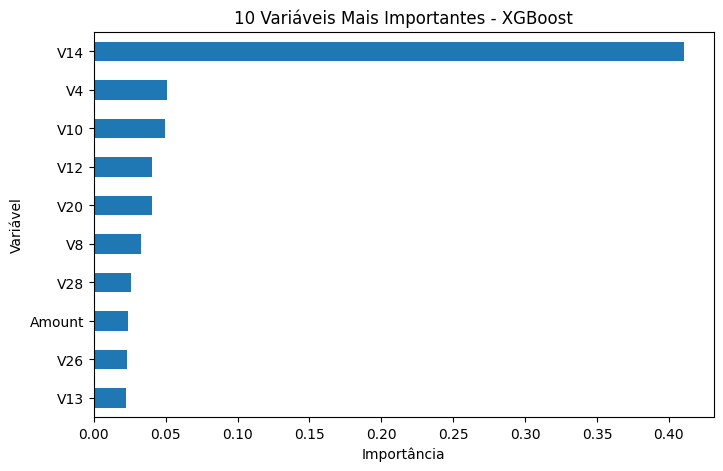

In [17]:
# Importância das variáveis no XGBoost
importancias = pd.Series(
    modelo_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Mostra as 10 variáveis mais importantes
top_10 = importancias.head(10)

print("10 variáveis mais importantes:")
print(top_10)

# Gráfico
plt.figure(figsize=(8, 5))
top_10.sort_values().plot(kind='barh')

plt.xlabel('Importância')
plt.ylabel('Variável')
plt.title('10 Variáveis Mais Importantes - XGBoost')
plt.show()

In [18]:
!pip install shap -q

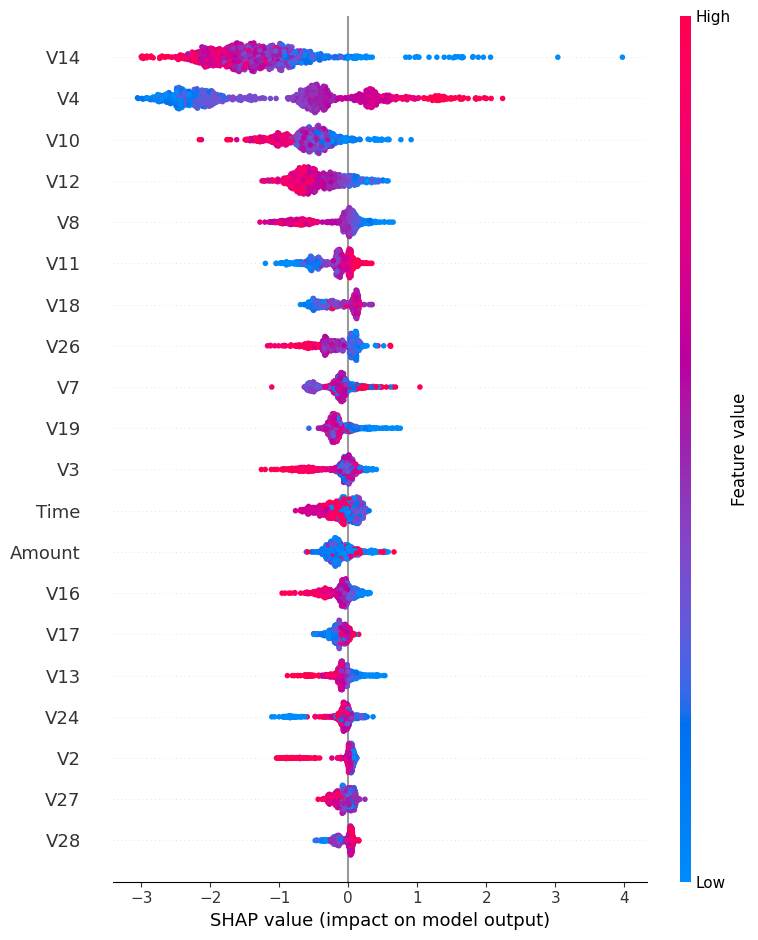

In [19]:
import shap

# Usa uma amostra para deixar o cálculo mais rápido
amostra_shap = X_test.sample(1000, random_state=42)

# Cria o explicador para o XGBoost
explainer = shap.TreeExplainer(modelo_xgb)

# Calcula os valores SHAP
shap_values = explainer.shap_values(amostra_shap)

# Gráfico de resumo
shap.summary_plot(shap_values, amostra_shap)

## 10. Conclusão

Os resultados demonstram que os modelos apresentam diferentes comportamentos na identificação de fraudes.

A Regressão Logística apresentou o maior recall entre os modelos utilizando o limiar padrão, identificando aproximadamente 91,84% das fraudes, porém com baixa precisão e grande quantidade de falsos positivos.

O Random Forest apresentou a maior precisão e o maior F1-Score para a classe fraude, mas obteve recall de aproximadamente 75,51%, deixando de identificar uma parcela maior das transações fraudulentas.

O XGBoost apresentou um equilíbrio entre esses comportamentos. Com o limiar padrão de 0,5, alcançou recall de aproximadamente 86,73%. Após o ajuste do limiar para 0,3, o recall aumentou para aproximadamente 89,80%, com redução da precisão para aproximadamente 18,57%.

A análise SHAP mostrou que variáveis como V14, V4, V10 e V12 tiveram grande influência nas previsões do XGBoost. Como as variáveis V1 a V28 foram transformadas por PCA, não é possível atribuir diretamente um significado original a cada uma delas.

O projeto evidencia a importância de analisar métricas além da acurácia em problemas com classes fortemente desbalanceadas e demonstra o impacto da escolha do limiar na relação entre detecção de fraudes e falsos positivos.